slide 1.
Our MQP attempts to generate meaningful connections between Machine Learning and Dynamical Systems/Chaos Theory. 


slide 2.

In order to understand our MQP and it's results we must first establish a basic understanding of dynamical systems as they apply to MLPs and machine learning architectures. 

A dynamical system describes how a state evolves in time according to a rule:

$f(x_t)= x_{t+1}$ 

Dynamical systems exist in both discrete and continuous forms. Because we however, are limited to computers we will only consider discrete time dynamical systems or "iterative maps". 

slide 3.
In many ways Neural Networks Exist as Iterative Maps. RNNs are dynamical systems, evolving an intial state until equilibrium is achieved. ResNets are discrete-time dynamical systems and approximate ODE flows. It is even possible to show how any aribitrary MLP defines an iterative map in the appropriate space.

slide 4.
Analyzing the iterative denoising map.

For our research we focus on analyzing the iterative map created by repeatedly applying a Denoising Auto Encoder(DAE) to its own outputs. The DAE consists of a fully connected(MLP) architecture, and is trained to denoise MNIST images with gaussian noise applied. The dynamical system emerges when we take the models output and recursively feed it back in as input.

Typically, a DAE performs a single mapping $f(x) \rightarrow \hat{y}$ 

we instead treat it as the recurance $f(x_t) \rightarrow x_{t+1}$

Producing a discrete time dynamical system.

slide 5.
Now that we've turned our DAE into an iterative map what do we get? 

Iterative maps have many interesting characteristics that tell us something about the system they create.
1. Fixed points: $f(x^*) = x^*$. Trajectories may flow twoards, away from or sit near fixed points. 
2. Attractors: Sets twoards which trajectories in a region (basin) converge over time. 
3. Contraction and Expansion: A map may push states closer together, further apart, or a mix of both. This determines whether the system stabilizes, diverges or becomes chaotic.

In the abstract sense this tells us the structure of the system and the important behaviors/regions within it. That sounds cool but really doesn't actually mean anything without context. So what could all of this actually tell us in practice?

By evaluting the DAE as an iterative map we ask what deep function has the network learned? 

slide 6. 
Approximating the manifold. 
The MNIST dataset does not occupy the full 784 pixel space. Rather, it occupies a low-dimensional submanifold of the space. Autoencoders are especially relevant here as they learn to compress higher-dimensional data to a meaningful representation in a lowerdimensional space. A DAE learns to map off-manifold noisy inputs toward the data manifold. Iterating the DAE allows us to observe how the model understands the shape and structure of this manifold. 

- Does off manifold data get pulled to the manifold and stay there over time? 
- Are certain regions of the manifold attracting? Many trajectories converging to a few small regions/points could reveal meaningful structures that exist in the data and were unintentionally learned by the network. 
- If trajectories are pushed apart what boundaries cause them to seperate?


Using random seed: 6
torch.Size([128, 1, 28, 28]) torch.Size([128, 1, 28, 28])


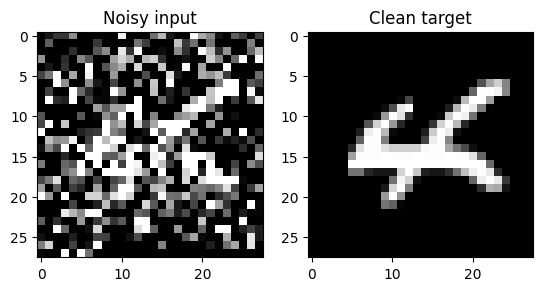

In [32]:
import random
import torch
import torchvision 
import matplotlib.pyplot as plt
import sklearn
import numpy as np
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

SEED = 6
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print(f"Using random seed: {SEED}")

transform = transforms.ToTensor()
train_data = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
test_data  = datasets.MNIST(root='./data', train=False, transform=transform, download=True)

class NoisyMNIST(Dataset):
    def __init__(self, mnist_dataset, noise_factor=0.01):
        self.mnist = mnist_dataset
        self.noise_factor = noise_factor

    def __len__(self):
        return len(self.mnist)
    
    def add_noise(self, img, sigma =.23):
        """
        Add zero-mean Gaussian noise to an MNIST image tensor in [0, 1].
        
        Args:
            img (torch.Tensor): Input image tensor, shape (C, H, W), values in [0, 1].
            sigma (float): Standard deviation of the Gaussian noise.
        
        Returns:
            torch.Tensor: Noisy image, same shape, clamped to [0, 1].
        """
        # Generate zero-mean Gaussian noise
        noise = torch.randn_like(img) * sigma
        
        # Add noise symmetrically (can brighten or darken)
        noisy = img + noise
        # Clamp to valid range
        noisy = torch.clamp(noisy, 0., 1.)
        return noisy
    

    def __getitem__(self, idx):
        # y = clean image (target)
        y, label = self.mnist[idx]
        # x = noisy image (input)
        x = self.add_noise(y, sigma=self.noise_factor)
        return x, y  # return noisy-clean pair

batch_size = 128

train_loader = DataLoader(
    NoisyMNIST(train_data, noise_factor=0.65),
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    NoisyMNIST(test_data, noise_factor=0.65),
    batch_size=batch_size,
    shuffle=False
)

x, y = next(iter(train_loader))
print(x.shape, y.shape)
# -> torch.Size([128, 1, 28, 28]) torch.Size([128, 1, 28, 28])

plt.subplot(1,2,1)
plt.title("Noisy input")
plt.imshow(x[0][0].detach().cpu(), cmap="gray")
plt.subplot(1,2,2)
plt.title("Clean target")
plt.imshow(y[0][0].detach().cpu(), cmap="gray")
plt.show()

Using device: mps
Epoch [1/15]  Train Loss: 0.0649  Val Loss: 0.0473
Epoch [2/15]  Train Loss: 0.0411  Val Loss: 0.0369
Epoch [3/15]  Train Loss: 0.0355  Val Loss: 0.0331
Epoch [4/15]  Train Loss: 0.0321  Val Loss: 0.0302
Epoch [5/15]  Train Loss: 0.0299  Val Loss: 0.0288
Epoch [6/15]  Train Loss: 0.0285  Val Loss: 0.0276
Epoch [7/15]  Train Loss: 0.0275  Val Loss: 0.0268
Epoch [8/15]  Train Loss: 0.0267  Val Loss: 0.0260
Epoch [9/15]  Train Loss: 0.0260  Val Loss: 0.0254
Epoch [10/15]  Train Loss: 0.0254  Val Loss: 0.0246
Epoch [11/15]  Train Loss: 0.0248  Val Loss: 0.0244
Epoch [12/15]  Train Loss: 0.0243  Val Loss: 0.0237
Epoch [13/15]  Train Loss: 0.0238  Val Loss: 0.0232
Epoch [14/15]  Train Loss: 0.0234  Val Loss: 0.0228
Epoch [15/15]  Train Loss: 0.0231  Val Loss: 0.0226


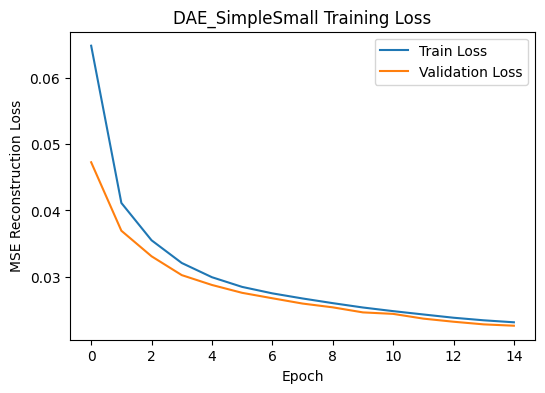

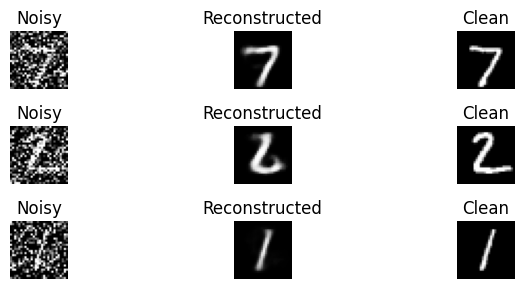

In [33]:
import torch.nn as nn
class DAE_SimpleSmall(nn.Module):
    """
    Simpler, smaller-capacity DAE for MNIST.
    Uses only Linear + ReLU + Sigmoid; no dropout/BN/skips.
    """
    def __init__(self, latent_dim=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 64),  nn.ReLU(),
            nn.Linear(64, latent_dim)      # linear bottleneck
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),  nn.ReLU(),
            nn.Linear(64, 256),         nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28))
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)
# --------------------------
# Training setup
# --------------------------
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")          # Apple GPU
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)
model = DAE_SimpleSmall(latent_dim=16).to(device)

criterion = nn.MSELoss()  # reconstruction loss (good for Gaussian noise)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Keep epochs logic as-is (adjust if you want)
num_epochs = 15

train_losses = []
val_losses = []

# --------------------------
# Training loop
# --------------------------
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0

    for x_noisy, x_clean in train_loader:
        x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

        optimizer.zero_grad()
        outputs = model(x_noisy)
        loss = criterion(outputs, x_clean)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_noisy.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)

    # Validation loop
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_noisy, x_clean in test_loader:
            x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
            outputs = model(x_noisy)
            loss = criterion(outputs, x_clean)
            val_loss += loss.item() * x_noisy.size(0)

    val_loss /= len(test_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}]  Train Loss: {epoch_loss:.4f}  Val Loss: {val_loss:.4f}")

    # Simple early stopping on plateau
    if epoch > 1 and abs(val_losses[-1] - val_losses[-2]) < 1e-5:
        print("Validation loss plateaued — stopping early.")
        break

# --------------------------
# Plot reconstruction loss
# --------------------------
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Reconstruction Loss")
plt.title("DAE_SimpleSmall Training Loss")
plt.legend()
plt.show()

# --------------------------
# Visualize reconstruction on test set
# --------------------------
model.eval()
x_noisy, x_clean = next(iter(test_loader))
x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)
with torch.no_grad():
    recon = model(x_noisy)

plt.figure(figsize=(8,3))
for i in range(3):
    plt.subplot(3,3,3*i+1)
    plt.imshow(x_noisy[i][0].cpu(), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    plt.subplot(3,3,3*i+2)
    plt.imshow(recon[i][0].cpu(), cmap="gray")
    plt.title("Reconstructed")
    plt.axis("off")

    plt.subplot(3,3,3*i+3)
    plt.imshow(x_clean[i][0].cpu(), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

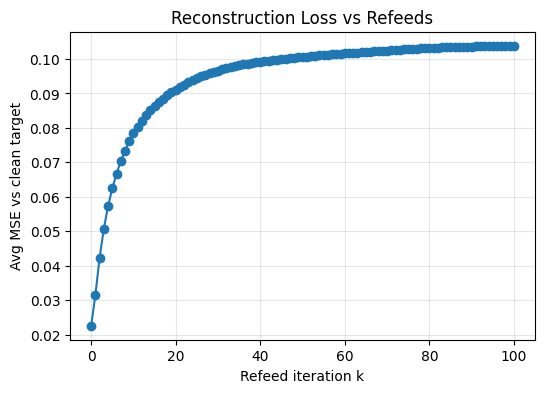

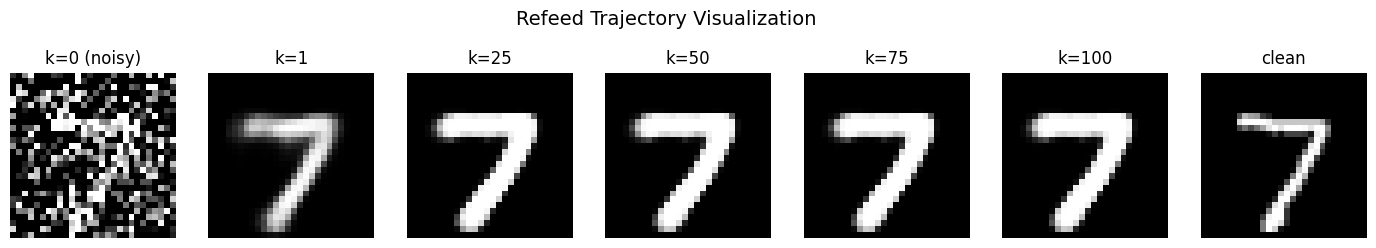

In [34]:
import os
os.makedirs("Photos", exist_ok=True)   # Create folder if not exists

# =====================================================================
# Evaluate refeeds (unchanged except for optional saving)
# =====================================================================
@torch.no_grad()
def evaluate_refeeds(model, loader, criterion, num_refeeds=5, device="cpu"):
    """
    Compute average reconstruction loss on the test set after k refeeds.
    k=0: one forward pass from noisy input.
    k=1: model(model(x_noisy)), etc.
    """
    model.eval()
    losses_by_k = [0.0 for _ in range(num_refeeds + 1)]
    count = 0

    for x_noisy, x_clean in loader:
        x_noisy = x_noisy.to(device)
        x_clean = x_clean.to(device)

        xk = x_noisy.clone()

        for k in range(num_refeeds + 1):
            out = model(xk)
            loss = criterion(out, x_clean)

            losses_by_k[k] += loss.item() * x_noisy.size(0)
            xk = out

        count += x_noisy.size(0)

    losses_by_k = [L / count for L in losses_by_k]
    return losses_by_k


# =====================================================================
# Run and plot loss curve, saving to Photos/
# =====================================================================
num_refeeds = 100
refeed_losses = evaluate_refeeds(model, test_loader, criterion, num_refeeds, device=device)

plt.figure(figsize=(6,4))
plt.plot(range(num_refeeds + 1), refeed_losses, marker="o")
plt.xlabel("Refeed iteration k")
plt.ylabel("Avg MSE vs clean target")
plt.title("Reconstruction Loss vs Refeeds")
plt.grid(True, alpha=0.3)

plt.savefig("Photos/refeed_loss_curve.png", dpi=300, bbox_inches="tight")
plt.show()


# =====================================================================
# Visualization of specific sample trajectory with correct k-labels
# =====================================================================
@torch.no_grad()
def visualize_refeeds(model, loader, device="cpu", num_refeeds=10, idx=0):

    model.eval()
    x_noisy, x_clean = next(iter(loader))
    x_noisy, x_clean = x_noisy.to(device), x_clean.to(device)

    # State variables
    xk = x_noisy.clone()

    # Always show k=0 (initial noisy input)
    imgs = [(x_noisy[idx:idx+1].cpu(), "k=0 (noisy)")]

    # Select ks to visualize: 1, 25%, 50%, 75%, 100%
    ks_to_show = sorted(set([
        1,
        max(1, round(num_refeeds * 0.25)),
        max(1, round(num_refeeds * 0.50)),
        max(1, round(num_refeeds * 0.75)),
        num_refeeds
    ]))

    # Iterate through refeeds
    for k in range(1, num_refeeds + 1):
        xk = model(xk)
        if k in ks_to_show:
            imgs.append((xk[idx:idx+1].cpu(), f"k={k}"))

    # Append clean image
    imgs.append((x_clean[idx:idx+1].cpu(), "clean"))

    # Create figure
    plt.figure(figsize=(2.5 * len(imgs), 3))

    for i, (img, title) in enumerate(imgs):
        plt.subplot(1, len(imgs), i + 1)
        plt.imshow(img[0,0], cmap="gray")
        plt.title(title)
        plt.axis("off")

    plt.suptitle("Refeed Trajectory Visualization", fontsize=14)

    # Save to Photos/
    plt.savefig(f"Photos/sample_refeeds_idx{idx}.png", dpi=300, bbox_inches="tight")
    plt.show()


# Example usage
visualize_refeeds(model, test_loader, device=device, num_refeeds=num_refeeds, idx=0)

In [35]:
# -------------------------------------------------------
# Compute epsilon based on average nearest-neighbor distance
# within each digit class in the LATENT space (16-d)
# -------------------------------------------------------
@torch.no_grad()
def compute_epsilon_latent(model, device="cpu"):
    """
    Encode clean MNIST test images into latent space,
    then compute mean intra-class nearest-neighbor distance
    in the 16-d latent space.
    """
    transform = transforms.Compose([transforms.ToTensor()])
    clean_test = torchvision.datasets.MNIST(
        root=".", train=False, download=True, transform=transform
    )

    model.eval()
    class_groups = {k: [] for k in range(10)}
    for img, label in clean_test:
        img = img.unsqueeze(0).to(device)  # [1, 1, 28, 28]
        z = model.encoder(img).squeeze(0)   # [16]
        class_groups[label].append(z)

    avg_nn_dists = {}
    for digit in range(10):
        Z = torch.stack(class_groups[digit])  # [n_c, 16]
        dist_matrix = torch.cdist(Z, Z, p=2)  # [n_c, n_c]
        dist_matrix.fill_diagonal_(float("inf"))
        nn_dists, _ = dist_matrix.min(dim=1)
        avg_nn_dists[digit] = nn_dists.mean().item()

    epsilon_latent = sum(avg_nn_dists.values()) / 10.0
    return avg_nn_dists, epsilon_latent


avg_nn_dists, epsilon_latent = compute_epsilon_latent(model, device=device)

print("\nAverage nearest-neighbor distance per digit class (latent space, 16-d):")
for d in range(10):
    print(f"Digit {d}: {avg_nn_dists[d]:.5f}")

print(f"\nFinal epsilon_latent (mean of class NN radii in latent space): {epsilon_latent:.5f}")



Average nearest-neighbor distance per digit class (latent space, 16-d):
Digit 0: 3.71948
Digit 1: 1.64626
Digit 2: 4.26014
Digit 3: 3.89552
Digit 4: 4.19550
Digit 5: 4.19108
Digit 6: 3.83459
Digit 7: 3.59961
Digit 8: 4.57795
Digit 9: 4.11093

Final epsilon_latent (mean of class NN radii in latent space): 3.80310


In [36]:
from tqdm import tqdm
import torch

def find_halt(steps, eps):
    """
    steps: list of per-step distances d_t = ||z_{t+1} - z_t|| in latent space
    eps: tolerance on total movement of the tail

    Returns earliest index i such that sum_{t=i}^{T-1} steps[t] <= eps.
    """
    hlt_indx = len(steps)
    suffix_sum = 0.0
    for i in range(len(steps)-1, -1, -1):
        suffix_sum += steps[i]
        if suffix_sum <= eps:
            hlt_indx = i
        else:
            break
    return hlt_indx

@torch.no_grad()
def find_attractor_indices(model, loader, num_steps, eps_latent, device="cpu"):
    """
    Unroll num_steps refeeds for each sample.
    All distances are computed in the 16-d latent space via
    g(z) = encoder(decoder(z)).

    For each trajectory:
      - Compute per-step distances d_t = ||z_{t+1} - z_t|| in latent space.
      - Compute halting index via tail sum <= eps_latent.
      - Save z_1 (after first pass) and z_T (after num_steps passes).

    Returns:
      all_halt_indices: np.array shape [N]
      z_first_all:     torch.Tensor [N, latent_dim] (after 1 pass)
      z_final_all:     torch.Tensor [N, latent_dim] (after num_steps)
      step_dists_all:  torch.Tensor [N, num_steps] (per-step latent distances)
    """
    model.eval()
    encoder = model.encoder
    decoder = model.decoder
    all_halt_indices = []
    z_first_batches = []
    z_final_batches = []
    step_dists_batches = []

    for x_noisy, _ in tqdm(loader, desc="Processing trajectories (latent space)"):
        x_noisy = x_noisy.to(device)
        batch_size = x_noisy.size(0)

        # Encode noisy input to get z_0
        z_t = encoder(x_noisy)  # [B, latent_dim]
        batch_dists = []

        for t in range(num_steps):
            # Latent-to-latent map: g(z) = encoder(decoder(z))
            z_next = encoder(decoder(z_t))
            d = torch.norm(z_next - z_t, p=2, dim=1)  # [B]
            batch_dists.append(d.unsqueeze(1))

            if t == 0:
                z_first_batches.append(z_next.cpu())

            z_t = z_next

        z_final_batches.append(z_t.cpu())
        batch_dists = torch.cat(batch_dists, dim=1)  # [B, num_steps]
        step_dists_batches.append(batch_dists.cpu())

        for b in range(batch_size):
            d_row = batch_dists[b].tolist()
            halt_idx = find_halt(d_row, eps_latent)
            all_halt_indices.append(halt_idx)

    z_first_all = torch.cat(z_first_batches, dim=0)    # [N, latent_dim]
    z_final_all = torch.cat(z_final_batches, dim=0)    # [N, latent_dim]
    step_dists_all = torch.cat(step_dists_batches, dim=0)  # [N, num_steps]
    all_halt_indices = np.array(all_halt_indices, dtype=np.int64)

    return all_halt_indices, z_first_all, z_final_all, step_dists_all

# --------------------------
# Run trajectory analysis in latent space
# --------------------------

epsilon_state = 0.1 * epsilon_latent
print(f"Using halting epsilon = {epsilon_state:.6f} (10% of latent-space intra-class NN radius)")

num_steps_for_clustering = 500
all_halt_indices, z_first, z_final, step_dists_matrix = find_attractor_indices(
    model,
    test_loader,
    num_steps=num_steps_for_clustering,
    eps_latent=epsilon_state,
    device=device,
)

print(f"z_first shape: {z_first.shape}")
print(f"z_final shape: {z_final.shape}")
print(f"halt indices shape: {all_halt_indices.shape}")
print(f"step_dists matrix shape: {step_dists_matrix.shape}")


Using halting epsilon = 0.380310 (10% of latent-space intra-class NN radius)


Processing trajectories (latent space): 100%|██████████| 79/79 [00:27<00:00,  2.91it/s]

z_first shape: torch.Size([10000, 16])
z_final shape: torch.Size([10000, 16])
halt indices shape: (10000,)
step_dists matrix shape: torch.Size([10000, 500])


Step-distance matrix: 10000 trajectories x 500 steps (latent space, 16-d)


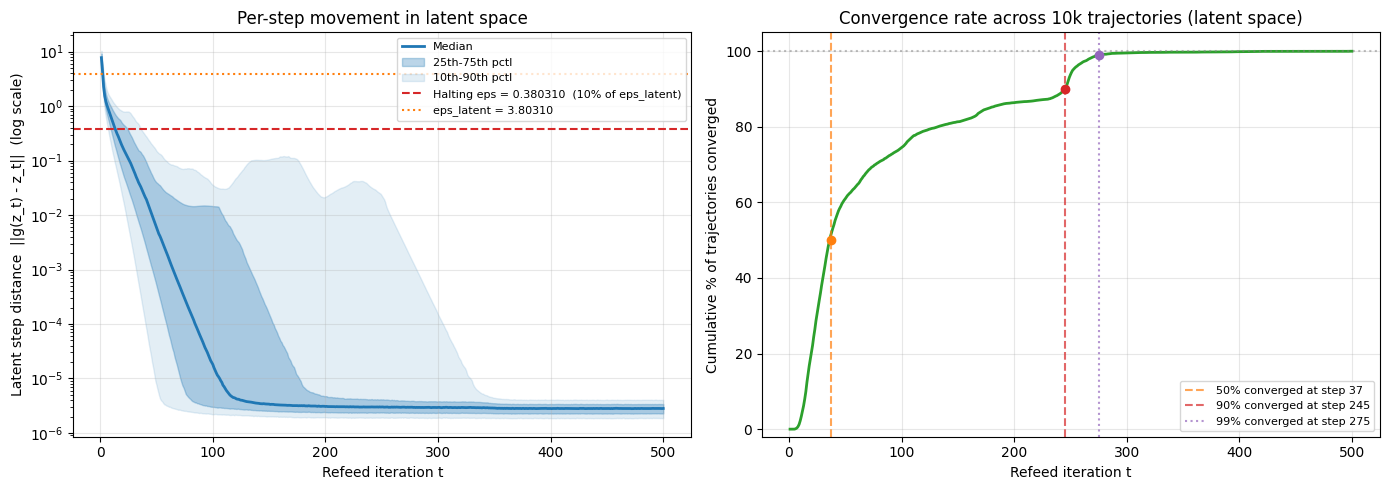


Convergence summary (latent space):
  eps_latent (intra-class NN) = 3.803105
  Halting eps (10% of above)  = 0.380310
  Trajectories: 10000
  Median halt index: 36
  Mean halt index:   76.1
  90th pctl halt:    244
  99th pctl halt:    274
  Never converged (halt >= 500): 0 (0.00%)


In [37]:
# =====================================================================
# Convergence-over-time plot for all 10k trajectories (latent space)
# =====================================================================

step_dists = step_dists_matrix.numpy()
N, T = step_dists.shape
print(f"Step-distance matrix: {N} trajectories x {T} steps (latent space, 16-d)")

original_epsilon = epsilon_latent
halting_eps = epsilon_state  # 10% of latent-space NN radius

# --- Figure: two-panel convergence plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ---- Panel 1: Step distance over time (median + percentile bands) ----
median_d = np.median(step_dists, axis=0)
p10 = np.percentile(step_dists, 10, axis=0)
p90 = np.percentile(step_dists, 90, axis=0)
p25 = np.percentile(step_dists, 25, axis=0)
p75 = np.percentile(step_dists, 75, axis=0)
steps = np.arange(1, T + 1)

ax1.semilogy(steps, median_d, color="tab:blue", linewidth=2, label="Median")
ax1.fill_between(steps, p25, p75, alpha=0.3, color="tab:blue", label="25th-75th pctl")
ax1.fill_between(steps, p10, p90, alpha=0.12, color="tab:blue", label="10th-90th pctl")

ax1.axhline(halting_eps, color="tab:red", linestyle="--", linewidth=1.5,
            label=f"Halting eps = {halting_eps:.6f}  (10% of eps_latent)")
ax1.axhline(original_epsilon, color="tab:orange", linestyle=":", linewidth=1.5,
            label=f"eps_latent = {original_epsilon:.5f}")

ax1.set_xlabel("Refeed iteration t")
ax1.set_ylabel("Latent step distance  ||g(z_t) - z_t||  (log scale)")
ax1.set_title("Per-step movement in latent space")
ax1.legend(fontsize=8, loc="upper right")
ax1.grid(True, alpha=0.3)

# ---- Panel 2: Cumulative fraction of trajectories converged by step t ----
halt_indices = np.array(all_halt_indices)
frac_converged = np.array(
    [(halt_indices <= t).sum() / N for t in range(T)]
)

ax2.plot(steps, frac_converged * 100, color="tab:green", linewidth=2)
ax2.axhline(100, color="gray", linestyle=":", alpha=0.5)

# Mark the step where 50%, 90%, 99% of trajectories have converged
for pct, color, ls in [(50, "tab:orange", "--"), (90, "tab:red", "--"), (99, "tab:purple", ":")]:
    idx = np.searchsorted(frac_converged, pct / 100.0)
    if idx < T:
        ax2.axvline(idx + 1, color=color, linestyle=ls, alpha=0.7,
                     label=f"{pct}% converged at step {idx + 1}")
        ax2.plot(idx + 1, pct, "o", color=color, markersize=6)

ax2.set_xlabel("Refeed iteration t")
ax2.set_ylabel("Cumulative % of trajectories converged")
ax2.set_title("Convergence rate across 10k trajectories (latent space)")
ax2.legend(fontsize=8, loc="lower right")
ax2.set_ylim(-2, 105)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("Photos/trajectory_convergence_over_time.png", dpi=300, bbox_inches="tight")
plt.show()

# Print summary stats
print(f"\nConvergence summary (latent space):")
print(f"  eps_latent (intra-class NN) = {original_epsilon:.6f}")
print(f"  Halting eps (10% of above)  = {halting_eps:.6f}")
print(f"  Trajectories: {N}")
print(f"  Median halt index: {int(np.median(halt_indices))}")
print(f"  Mean halt index:   {halt_indices.mean():.1f}")
print(f"  90th pctl halt:    {int(np.percentile(halt_indices, 90))}")
print(f"  99th pctl halt:    {int(np.percentile(halt_indices, 99))}")
never_converged = (halt_indices >= T).sum()
print(f"  Never converged (halt >= {T}): {never_converged} ({100*never_converged/N:.2f}%)")


z_first shape: (10000, 16)
[z_first] k= 4, silhouette=0.1636, ARI=0.2799, NMI=0.4164, purity=0.3709
[z_first] k= 5, silhouette=0.1819, ARI=0.2638, NMI=0.4162, purity=0.3679
[z_first] k= 6, silhouette=0.1965, ARI=0.2747, NMI=0.4349, purity=0.4257
[z_first] k= 7, silhouette=0.1963, ARI=0.3119, NMI=0.4625, purity=0.4771
[z_first] k= 8, silhouette=0.2038, ARI=0.3497, NMI=0.4937, purity=0.5320
[z_first] k= 9, silhouette=0.2063, ARI=0.3556, NMI=0.5004, purity=0.5625
[z_first] k=10, silhouette=0.2106, ARI=0.3682, NMI=0.5127, purity=0.5902
[z_first] k=11, silhouette=0.2059, ARI=0.3648, NMI=0.5056, purity=0.6000
[z_first] k=12, silhouette=0.2086, ARI=0.3857, NMI=0.5230, purity=0.6363
[z_first] k=13, silhouette=0.2077, ARI=0.3841, NMI=0.5279, purity=0.6433
[z_first] k=14, silhouette=0.2047, ARI=0.3770, NMI=0.5267, purity=0.6467
[z_first] k=15, silhouette=0.2047, ARI=0.3722, NMI=0.5359, purity=0.6630
[z_first] k=16, silhouette=0.2068, ARI=0.3630, NMI=0.5339, purity=0.6686
[z_first] k=17, silhouet

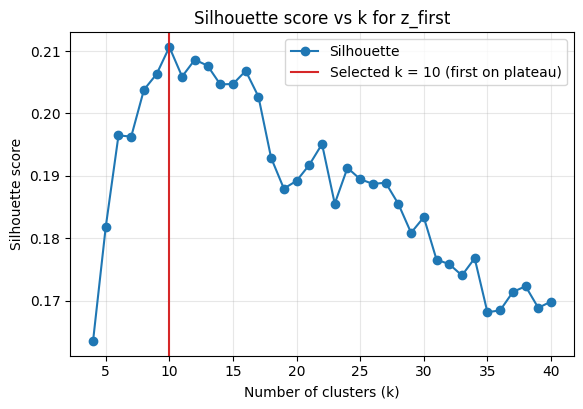

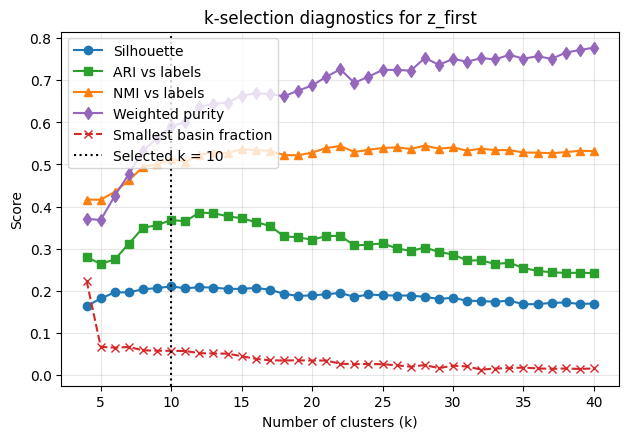


Selected k for z_first = 10 (first k on plateau, silhouette = 0.2106, peak was k=10 at 0.2106)


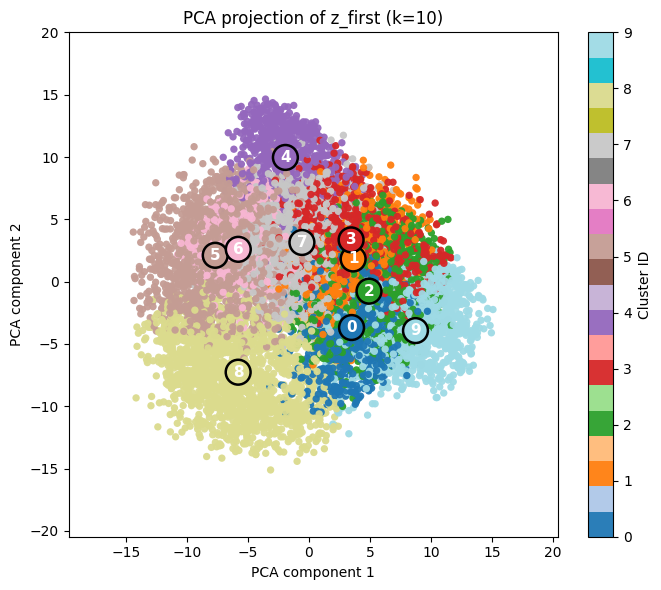

Saved PCA cluster plot -> Photos/z_first_pca_k10.png

Cluster composition for z_first (k=10):
  Cluster 0: n=651, top label=6 (92.63%)
  Cluster 1: n=839, top label=2 (87.13%)
  Cluster 2: n=1403, top label=3 (52.03%)
  Cluster 3: n=1053, top label=5 (36.94%)
  Cluster 4: n=714, top label=1 (82.21%)
  Cluster 5: n=1184, top label=7 (42.15%)
  Cluster 6: n=576, top label=1 (91.15%)
  Cluster 7: n=977, top label=8 (61.82%)
  Cluster 8: n=1670, top label=9 (35.45%)
  Cluster 9: n=933, top label=0 (68.81%)
z_final shape: (10000, 16)
[z_final] k= 4, silhouette=0.5379, ARI=0.2382, NMI=0.3922, purity=0.3779
[z_final] k= 5, silhouette=0.6049, ARI=0.2390, NMI=0.3854, purity=0.3905
[z_final] k= 6, silhouette=0.6492, ARI=0.2462, NMI=0.4057, purity=0.4371
[z_final] k= 7, silhouette=0.6880, ARI=0.2744, NMI=0.4440, purity=0.4978
[z_final] k= 8, silhouette=0.7290, ARI=0.3051, NMI=0.4718, purity=0.5433
[z_final] k= 9, silhouette=0.7662, ARI=0.2916, NMI=0.4731, purity=0.5390
[z_final] k=10, silhouette=

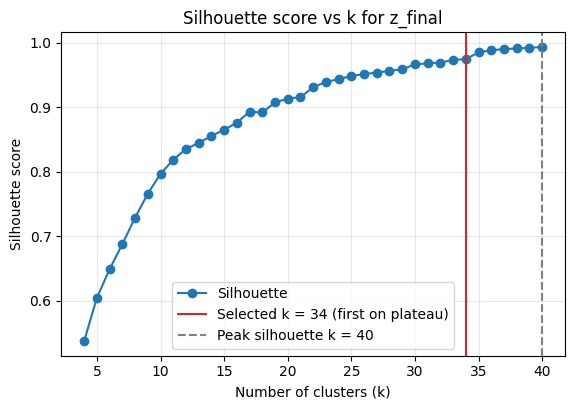

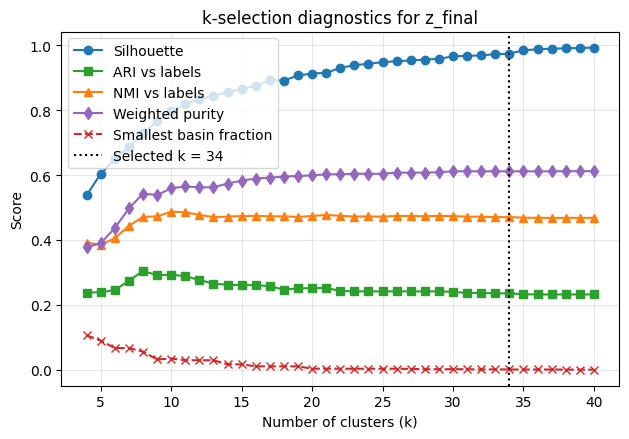


Selected k for z_final = 34 (first k on plateau, silhouette = 0.9747, peak was k=40 at 0.9934)

Fixed-point validation (z_final, k=34):
  Centroid 0: residual ||f(x*)-x*|| = 2.40e-06
  Centroid 1: residual ||f(x*)-x*|| = 2.51e-06
  Centroid 2: residual ||f(x*)-x*|| = 3.95e-06
  Centroid 3: residual ||f(x*)-x*|| = 2.17e-06
  Centroid 4: residual ||f(x*)-x*|| = 2.99e-06
  Centroid 5: residual ||f(x*)-x*|| = 2.88e-06
  Centroid 6: residual ||f(x*)-x*|| = 1.55e-06
  Centroid 7: residual ||f(x*)-x*|| = 1.72e-06
  Centroid 8: residual ||f(x*)-x*|| = 2.99e-06
  Centroid 9: residual ||f(x*)-x*|| = 1.90e-06
  Centroid 10: residual ||f(x*)-x*|| = 2.21e-06
  Centroid 11: residual ||f(x*)-x*|| = 2.15e-06
  Centroid 12: residual ||f(x*)-x*|| = 2.08e-06
  Centroid 13: residual ||f(x*)-x*|| = 1.95e-06
  Centroid 14: residual ||f(x*)-x*|| = 3.04e-06
  Centroid 15: residual ||f(x*)-x*|| = 2.84e-06
  Centroid 16: residual ||f(x*)-x*|| = 2.47e-06
  Centroid 17: residual ||f(x*)-x*|| = 2.08e-06
  Centroi

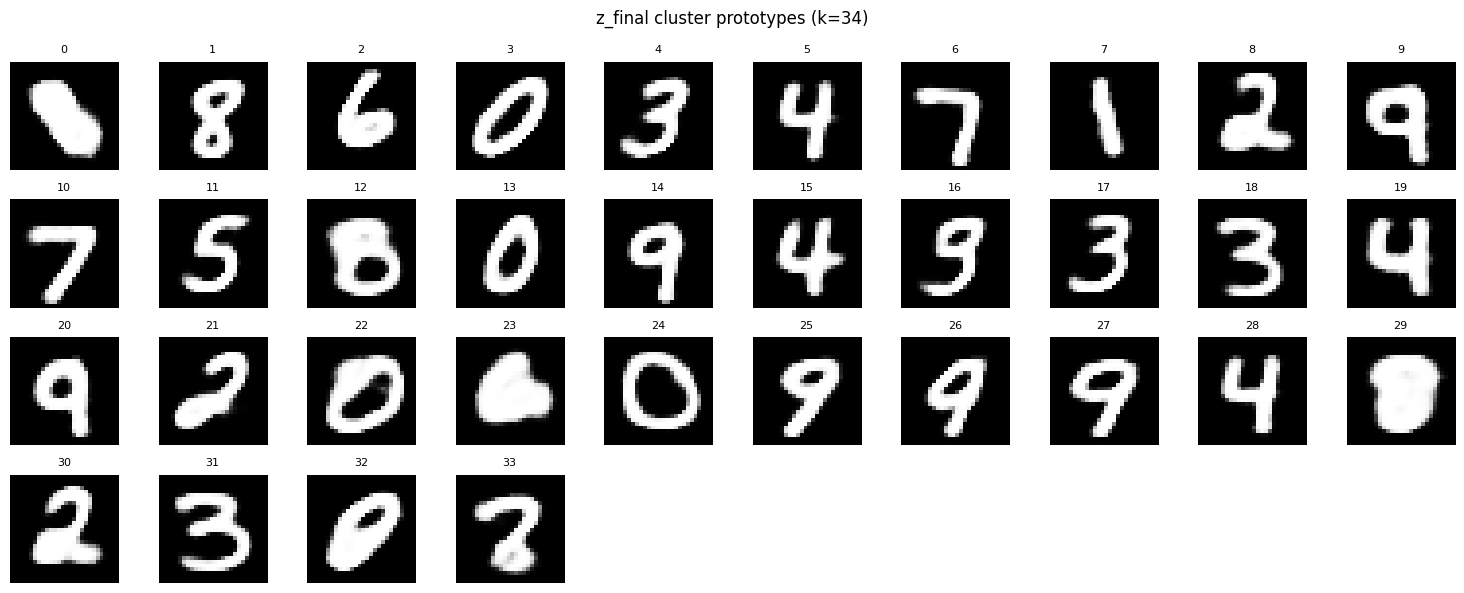

Saved prototypes for z_final -> Photos/z_final_prototypes_k34.png


/Users/traver/Desktop/MQP 2025/MNIST_DNAE/src/B_Term_Presentation/attractor_selection.py:331: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  transform=side_ax.transAxes,


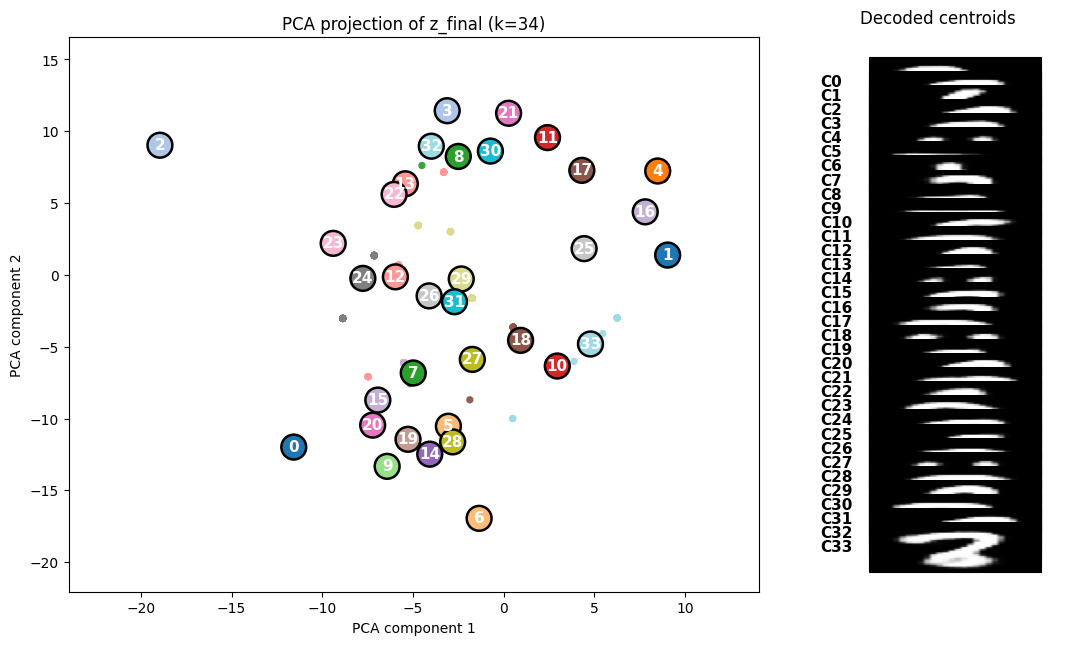

Saved PCA cluster plot -> Photos/z_final_pca_k34.png

Cluster composition for z_final (k=34):
  Cluster 0: n=344, top label=9 (45.93%)
  Cluster 1: n=3345, top label=8 (24.75%)
  Cluster 2: n=1064, top label=6 (83.36%)
  Cluster 3: n=614, top label=0 (95.11%)
  Cluster 4: n=388, top label=3 (78.35%)
  Cluster 5: n=386, top label=9 (50.52%)
  Cluster 6: n=506, top label=7 (89.53%)
  Cluster 7: n=542, top label=1 (82.47%)
  Cluster 8: n=195, top label=2 (98.46%)
  Cluster 9: n=42, top label=9 (66.67%)
  Cluster 10: n=417, top label=7 (87.29%)
  Cluster 11: n=168, top label=5 (73.81%)
  Cluster 12: n=48, top label=0 (56.25%)
  Cluster 13: n=169, top label=0 (84.02%)
  Cluster 14: n=164, top label=9 (79.88%)
  Cluster 15: n=265, top label=4 (76.98%)
  Cluster 16: n=317, top label=3 (74.76%)
  Cluster 17: n=125, top label=3 (88.80%)
  Cluster 18: n=48, top label=3 (81.25%)
  Cluster 19: n=107, top label=4 (89.72%)
  Cluster 20: n=159, top label=9 (59.12%)
  Cluster 21: n=34, top label=2 (94

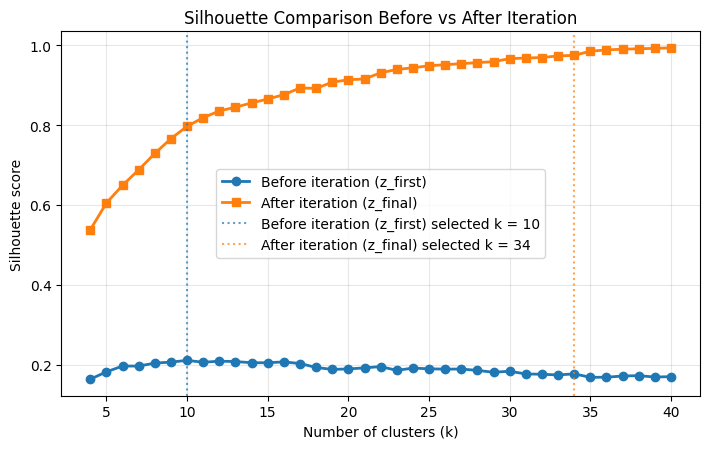

Saved combined silhouette comparison -> Photos/z_first_vs_z_final_silhouette.png


'Photos/z_first_vs_z_final_silhouette.png'

In [38]:
import importlib
import attractor_selection
importlib.reload(attractor_selection)
from attractor_selection import (
    cluster_and_plot_latents,
    plot_silhouette_comparison,
)

# z_first and z_final are already in latent space (returned by find_attractor_indices)

res_first = cluster_and_plot_latents(
    z_first,
    name="z_first",
    decoder=None,
    encoder=None,
    device=device,
    orig_labels=test_data.targets[:len(z_first)],
)

orig_labels = test_data.targets[:len(z_final)]

res_final = cluster_and_plot_latents(
    z_final,
    name="z_final",
    decoder=model.decoder,
    encoder=model.encoder,
    device=device,
    orig_labels=orig_labels,
)

plot_silhouette_comparison(
    res_first,
    res_final,
    before_label="Before iteration (z_first)",
    after_label="After iteration (z_final)",
)


In [39]:
import os
from IPython.display import Markdown, display

def make_cluster_table(name, proto_imgs, cluster_sizes, cluster_label_props):
    """
    proto_imgs: [K, 1, 28, 28]
    cluster_sizes: [K]
    cluster_label_props: [K, 10] (fractions)
    """
    out_dir = f"Photos/{name}_cluster_table"
    os.makedirs(out_dir, exist_ok=True)

    K = proto_imgs.shape[0]

    # Save prototype images
    img_paths = []
    for c in range(K):
        path = f"{out_dir}/cluster_{c}.png"
        plt.imsave(path, proto_imgs[c, 0], cmap="gray")
        img_paths.append(path)

    # Build markdown table
    header = "| Cluster | Prototype | Size | " + " | ".join([f"%{d}" for d in range(10)]) + " |"
    sep = "|--------|" + "---------|"*12

    rows = [header, sep]

    for c in range(K):
        img_md = f"![]({img_paths[c]})"
        size = cluster_sizes[c]
        perc = [f"{100*p:.1f}%" for p in cluster_label_props[c]]

        row = f"| {c} | {img_md} | {size} | " + " | ".join(perc) + " |"
        rows.append(row)

    display(Markdown("\n".join(rows)))

# Generate the table for z_final
make_cluster_table(
    name="z_final",
    proto_imgs=res_final["proto_imgs"],
    cluster_sizes=res_final["cluster_sizes"],
    cluster_label_props=res_final["cluster_label_props"],
)

| Cluster | Prototype | Size | %0 | %1 | %2 | %3 | %4 | %5 | %6 | %7 | %8 | %9 |
|--------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|---------|
| 0 | ![](Photos/z_final_cluster_table/cluster_0.png) | 344 | 6.7% | 0.0% | 4.4% | 12.2% | 12.8% | 4.9% | 2.0% | 7.0% | 4.1% | 45.9% |
| 1 | ![](Photos/z_final_cluster_table/cluster_1.png) | 3345 | 1.2% | 20.4% | 14.4% | 4.5% | 7.4% | 16.4% | 0.9% | 3.6% | 24.8% | 6.5% |
| 2 | ![](Photos/z_final_cluster_table/cluster_2.png) | 1064 | 2.2% | 0.5% | 6.2% | 1.2% | 1.8% | 2.3% | 83.4% | 0.3% | 1.9% | 0.3% |
| 3 | ![](Photos/z_final_cluster_table/cluster_3.png) | 614 | 95.1% | 0.0% | 1.6% | 0.3% | 0.7% | 0.2% | 1.1% | 0.2% | 0.3% | 0.5% |
| 4 | ![](Photos/z_final_cluster_table/cluster_4.png) | 388 | 2.6% | 0.5% | 7.2% | 78.4% | 0.0% | 8.2% | 0.0% | 0.3% | 2.1% | 0.8% |
| 5 | ![](Photos/z_final_cluster_table/cluster_5.png) | 386 | 0.0% | 0.0% | 0.3% | 0.0% | 43.0% | 1.0% | 0.0% | 3.4% | 1.8% | 50.5% |
| 6 | ![](Photos/z_final_cluster_table/cluster_6.png) | 506 | 0.2% | 0.0% | 0.8% | 1.4% | 1.0% | 1.2% | 0.2% | 89.5% | 0.8% | 4.9% |
| 7 | ![](Photos/z_final_cluster_table/cluster_7.png) | 542 | 0.2% | 82.5% | 1.8% | 5.4% | 1.8% | 1.5% | 0.7% | 2.6% | 1.5% | 2.0% |
| 8 | ![](Photos/z_final_cluster_table/cluster_8.png) | 195 | 0.0% | 0.0% | 98.5% | 0.0% | 0.5% | 0.0% | 0.5% | 0.5% | 0.0% | 0.0% |
| 9 | ![](Photos/z_final_cluster_table/cluster_9.png) | 42 | 0.0% | 0.0% | 9.5% | 0.0% | 16.7% | 0.0% | 0.0% | 7.1% | 0.0% | 66.7% |
| 10 | ![](Photos/z_final_cluster_table/cluster_10.png) | 417 | 0.2% | 0.0% | 1.9% | 1.4% | 0.7% | 2.6% | 0.2% | 87.3% | 1.0% | 4.6% |
| 11 | ![](Photos/z_final_cluster_table/cluster_11.png) | 168 | 3.0% | 0.0% | 0.6% | 19.0% | 0.0% | 73.8% | 0.0% | 0.0% | 2.4% | 1.2% |
| 12 | ![](Photos/z_final_cluster_table/cluster_12.png) | 48 | 56.2% | 0.0% | 0.0% | 6.2% | 0.0% | 8.3% | 2.1% | 0.0% | 25.0% | 2.1% |
| 13 | ![](Photos/z_final_cluster_table/cluster_13.png) | 169 | 84.0% | 0.0% | 3.0% | 3.0% | 0.6% | 1.2% | 1.2% | 1.2% | 5.3% | 0.6% |
| 14 | ![](Photos/z_final_cluster_table/cluster_14.png) | 164 | 0.0% | 0.0% | 1.2% | 0.6% | 12.2% | 0.6% | 0.0% | 4.9% | 0.6% | 79.9% |
| 15 | ![](Photos/z_final_cluster_table/cluster_15.png) | 265 | 0.8% | 0.0% | 3.0% | 0.0% | 77.0% | 1.9% | 3.0% | 2.3% | 4.5% | 7.5% |
| 16 | ![](Photos/z_final_cluster_table/cluster_16.png) | 317 | 0.3% | 0.0% | 0.0% | 74.8% | 0.0% | 19.6% | 0.0% | 0.3% | 2.8% | 2.2% |
| 17 | ![](Photos/z_final_cluster_table/cluster_17.png) | 125 | 1.6% | 0.0% | 2.4% | 88.8% | 0.0% | 4.8% | 0.8% | 1.6% | 0.0% | 0.0% |
| 18 | ![](Photos/z_final_cluster_table/cluster_18.png) | 48 | 0.0% | 0.0% | 2.1% | 81.2% | 0.0% | 4.2% | 0.0% | 0.0% | 10.4% | 2.1% |
| 19 | ![](Photos/z_final_cluster_table/cluster_19.png) | 107 | 0.0% | 0.0% | 0.9% | 0.9% | 89.7% | 0.0% | 1.9% | 0.9% | 0.9% | 4.7% |
| 20 | ![](Photos/z_final_cluster_table/cluster_20.png) | 159 | 0.0% | 0.0% | 4.4% | 0.0% | 32.1% | 3.1% | 0.0% | 0.6% | 0.6% | 59.1% |
| 21 | ![](Photos/z_final_cluster_table/cluster_21.png) | 34 | 0.0% | 0.0% | 94.1% | 0.0% | 0.0% | 2.9% | 0.0% | 2.9% | 0.0% | 0.0% |
| 22 | ![](Photos/z_final_cluster_table/cluster_22.png) | 44 | 97.7% | 0.0% | 0.0% | 0.0% | 0.0% | 0.0% | 0.0% | 0.0% | 2.3% | 0.0% |
| 23 | ![](Photos/z_final_cluster_table/cluster_23.png) | 29 | 10.3% | 0.0% | 75.9% | 3.4% | 3.4% | 0.0% | 6.9% | 0.0% | 0.0% | 0.0% |
| 24 | ![](Photos/z_final_cluster_table/cluster_24.png) | 44 | 97.7% | 0.0% | 0.0% | 0.0% | 0.0% | 0.0% | 2.3% | 0.0% | 0.0% | 0.0% |
| 25 | ![](Photos/z_final_cluster_table/cluster_25.png) | 40 | 0.0% | 0.0% | 0.0% | 0.0% | 7.5% | 2.5% | 0.0% | 12.5% | 0.0% | 77.5% |
| 26 | ![](Photos/z_final_cluster_table/cluster_26.png) | 19 | 0.0% | 0.0% | 0.0% | 0.0% | 36.8% | 0.0% | 0.0% | 0.0% | 0.0% | 63.2% |
| 27 | ![](Photos/z_final_cluster_table/cluster_27.png) | 39 | 2.6% | 0.0% | 0.0% | 0.0% | 12.8% | 0.0% | 0.0% | 2.6% | 2.6% | 79.5% |
| 28 | ![](Photos/z_final_cluster_table/cluster_28.png) | 94 | 0.0% | 0.0% | 0.0% | 0.0% | 89.4% | 3.2% | 1.1% | 0.0% | 1.1% | 5.3% |
| 29 | ![](Photos/z_final_cluster_table/cluster_29.png) | 47 | 29.8% | 0.0% | 8.5% | 4.3% | 6.4% | 6.4% | 0.0% | 0.0% | 36.2% | 8.5% |
| 30 | ![](Photos/z_final_cluster_table/cluster_30.png) | 124 | 0.0% | 0.0% | 98.4% | 1.6% | 0.0% | 0.0% | 0.0% | 0.0% | 0.0% | 0.0% |
| 31 | ![](Photos/z_final_cluster_table/cluster_31.png) | 47 | 4.3% | 0.0% | 0.0% | 48.9% | 0.0% | 40.4% | 0.0% | 0.0% | 4.3% | 2.1% |
| 32 | ![](Photos/z_final_cluster_table/cluster_32.png) | 16 | 68.8% | 0.0% | 18.8% | 0.0% | 0.0% | 0.0% | 6.2% | 0.0% | 0.0% | 6.2% |
| 33 | ![](Photos/z_final_cluster_table/cluster_33.png) | 10 | 20.0% | 0.0% | 10.0% | 0.0% | 0.0% | 0.0% | 0.0% | 40.0% | 30.0% | 0.0% |

Saved annotated prototypes → Photos/z_final_prototypes_annotated_clean.png


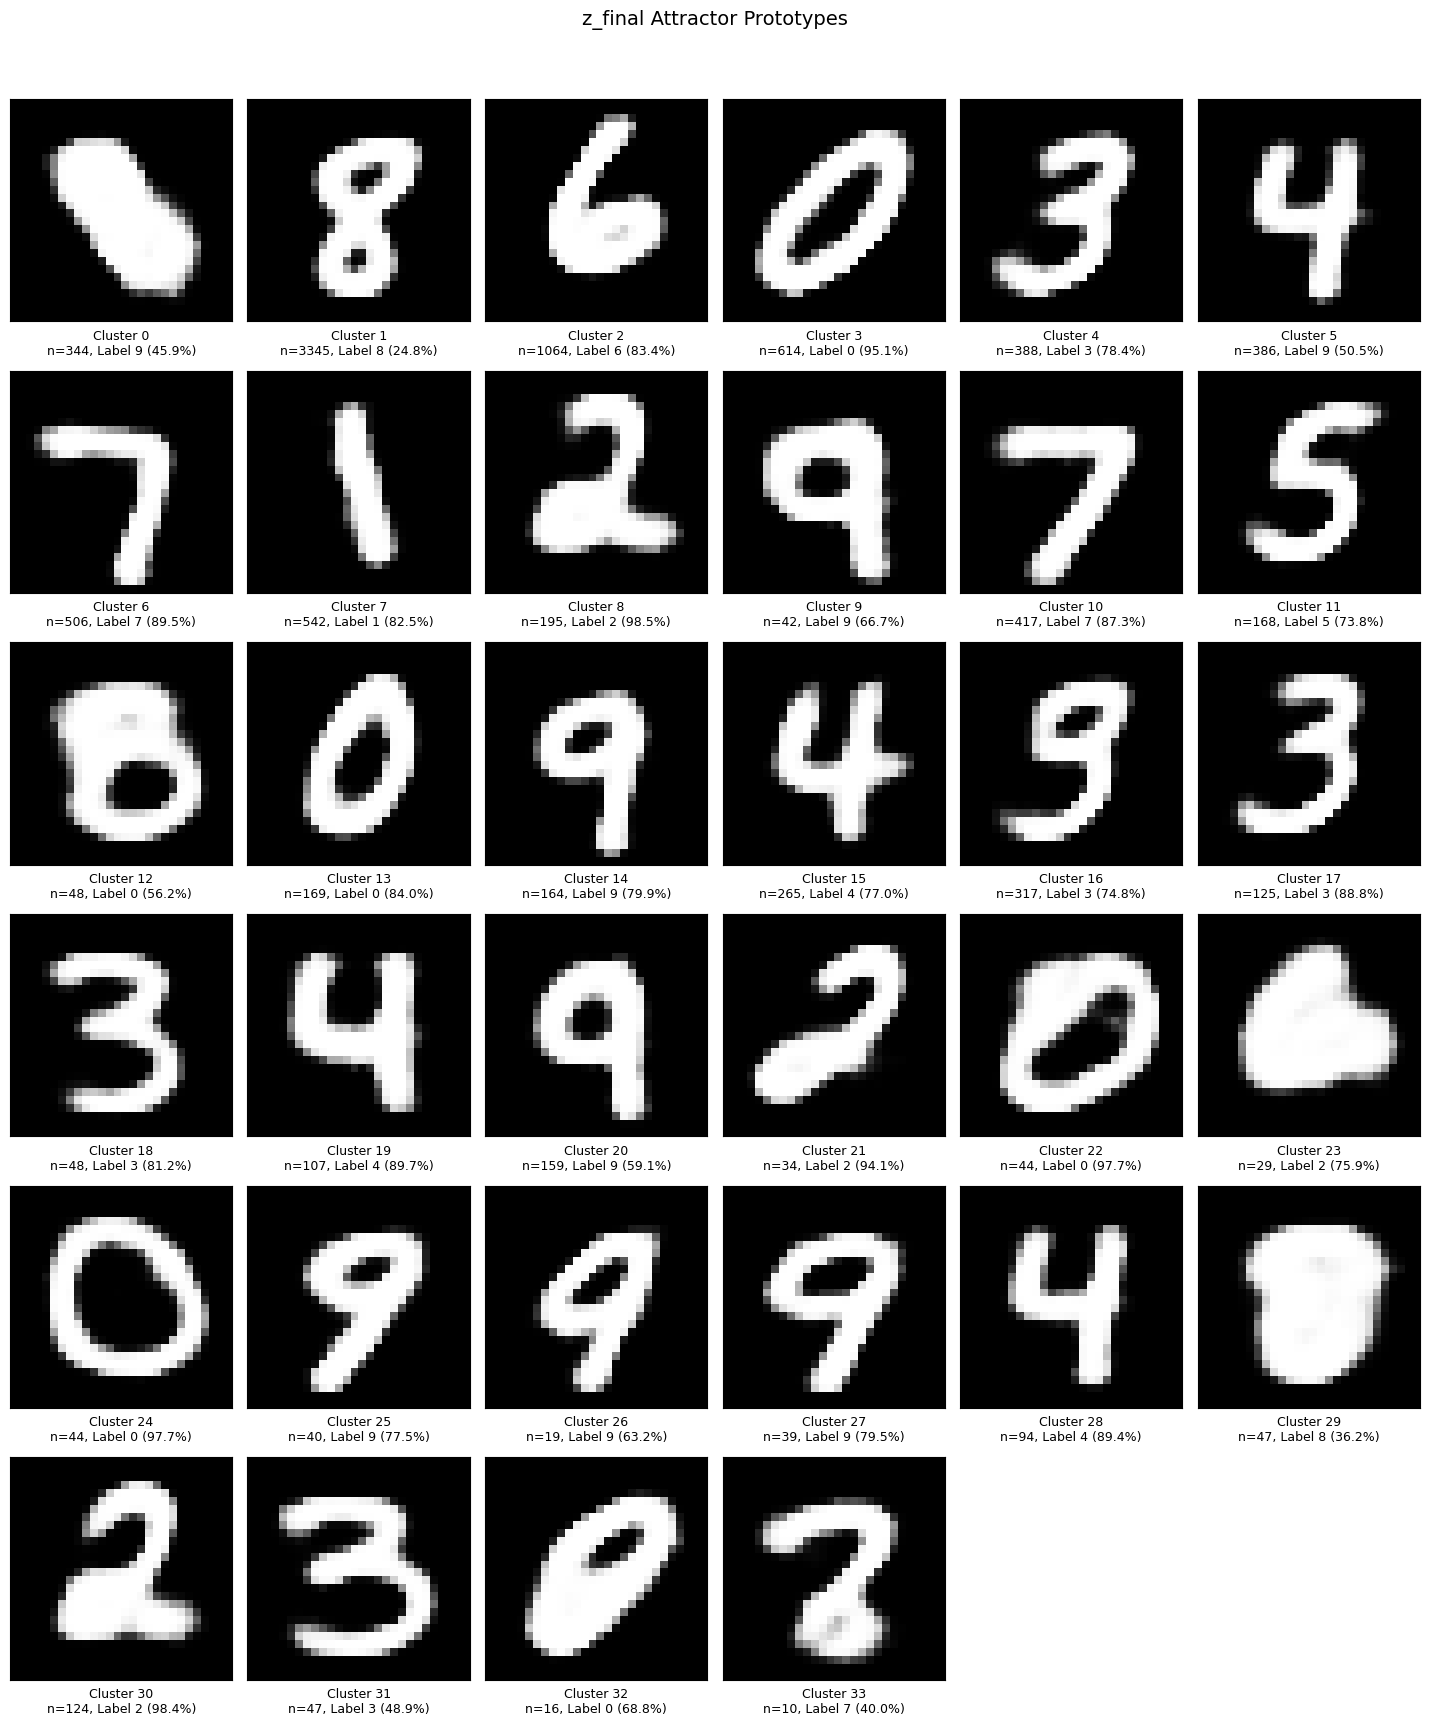

In [40]:
import math
import matplotlib.pyplot as plt
import numpy as np

def show_attractor_prototypes(
    name,
    proto_imgs,
    cluster_sizes,
    cluster_label_props,
    save=True,
    fontsize=10,
):
    """
    proto_imgs: [K, 1, H, W]
    cluster_sizes: [K]
    cluster_label_props: [K, 10]
    """
    K = proto_imgs.shape[0]
    n_cols = min(6, K)
    n_rows = math.ceil(K / n_cols)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(2.4 * n_cols, 2.8 * n_rows),
        squeeze=False
    )

    for idx in range(n_rows * n_cols):
        r = idx // n_cols
        c = idx % n_cols
        ax = axes[r][c]

        if idx >= K:
            ax.axis("off")
            continue

        # Image
        ax.imshow(proto_imgs[idx, 0], cmap="gray")

        # Remove tick marks
        ax.set_xticks([])
        ax.set_yticks([])

        # Get cluster stats
        n = cluster_sizes[idx]
        props = cluster_label_props[idx]
        top_label = int(np.argmax(props))
        top_prop = props[top_label] * 100.0

        # Put a clean, readable label BELOW the image
        ax.set_xlabel(
            f"Cluster {idx}\nn={n}, Label {top_label} ({top_prop:.1f}%)",
            fontsize=fontsize,
            labelpad=6
        )

    plt.suptitle(f"{name} Attractor Prototypes", fontsize=14, y=1.02)
    plt.tight_layout()

    if save:
        out_path = f"Photos/{name}_prototypes_annotated_clean.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Saved annotated prototypes → {out_path}")

    plt.show()

show_attractor_prototypes(
    name="z_final",
    proto_imgs=res_final["proto_imgs"],
    cluster_sizes=res_final["cluster_sizes"],
    cluster_label_props=res_final["cluster_label_props"],
    fontsize=9
)

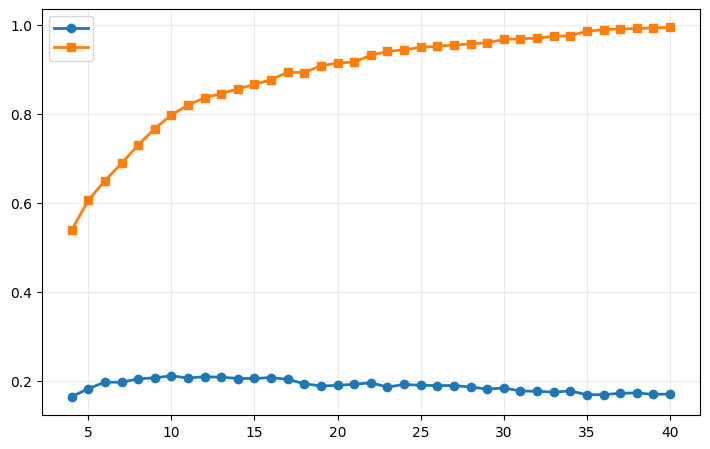

Saved overlay-only silhouette plot -> Photos/z_first_vs_z_final_silhouette_overlay.png
Saved selected attractor summary -> Photos/z_final_selected_attractor_distributions.png


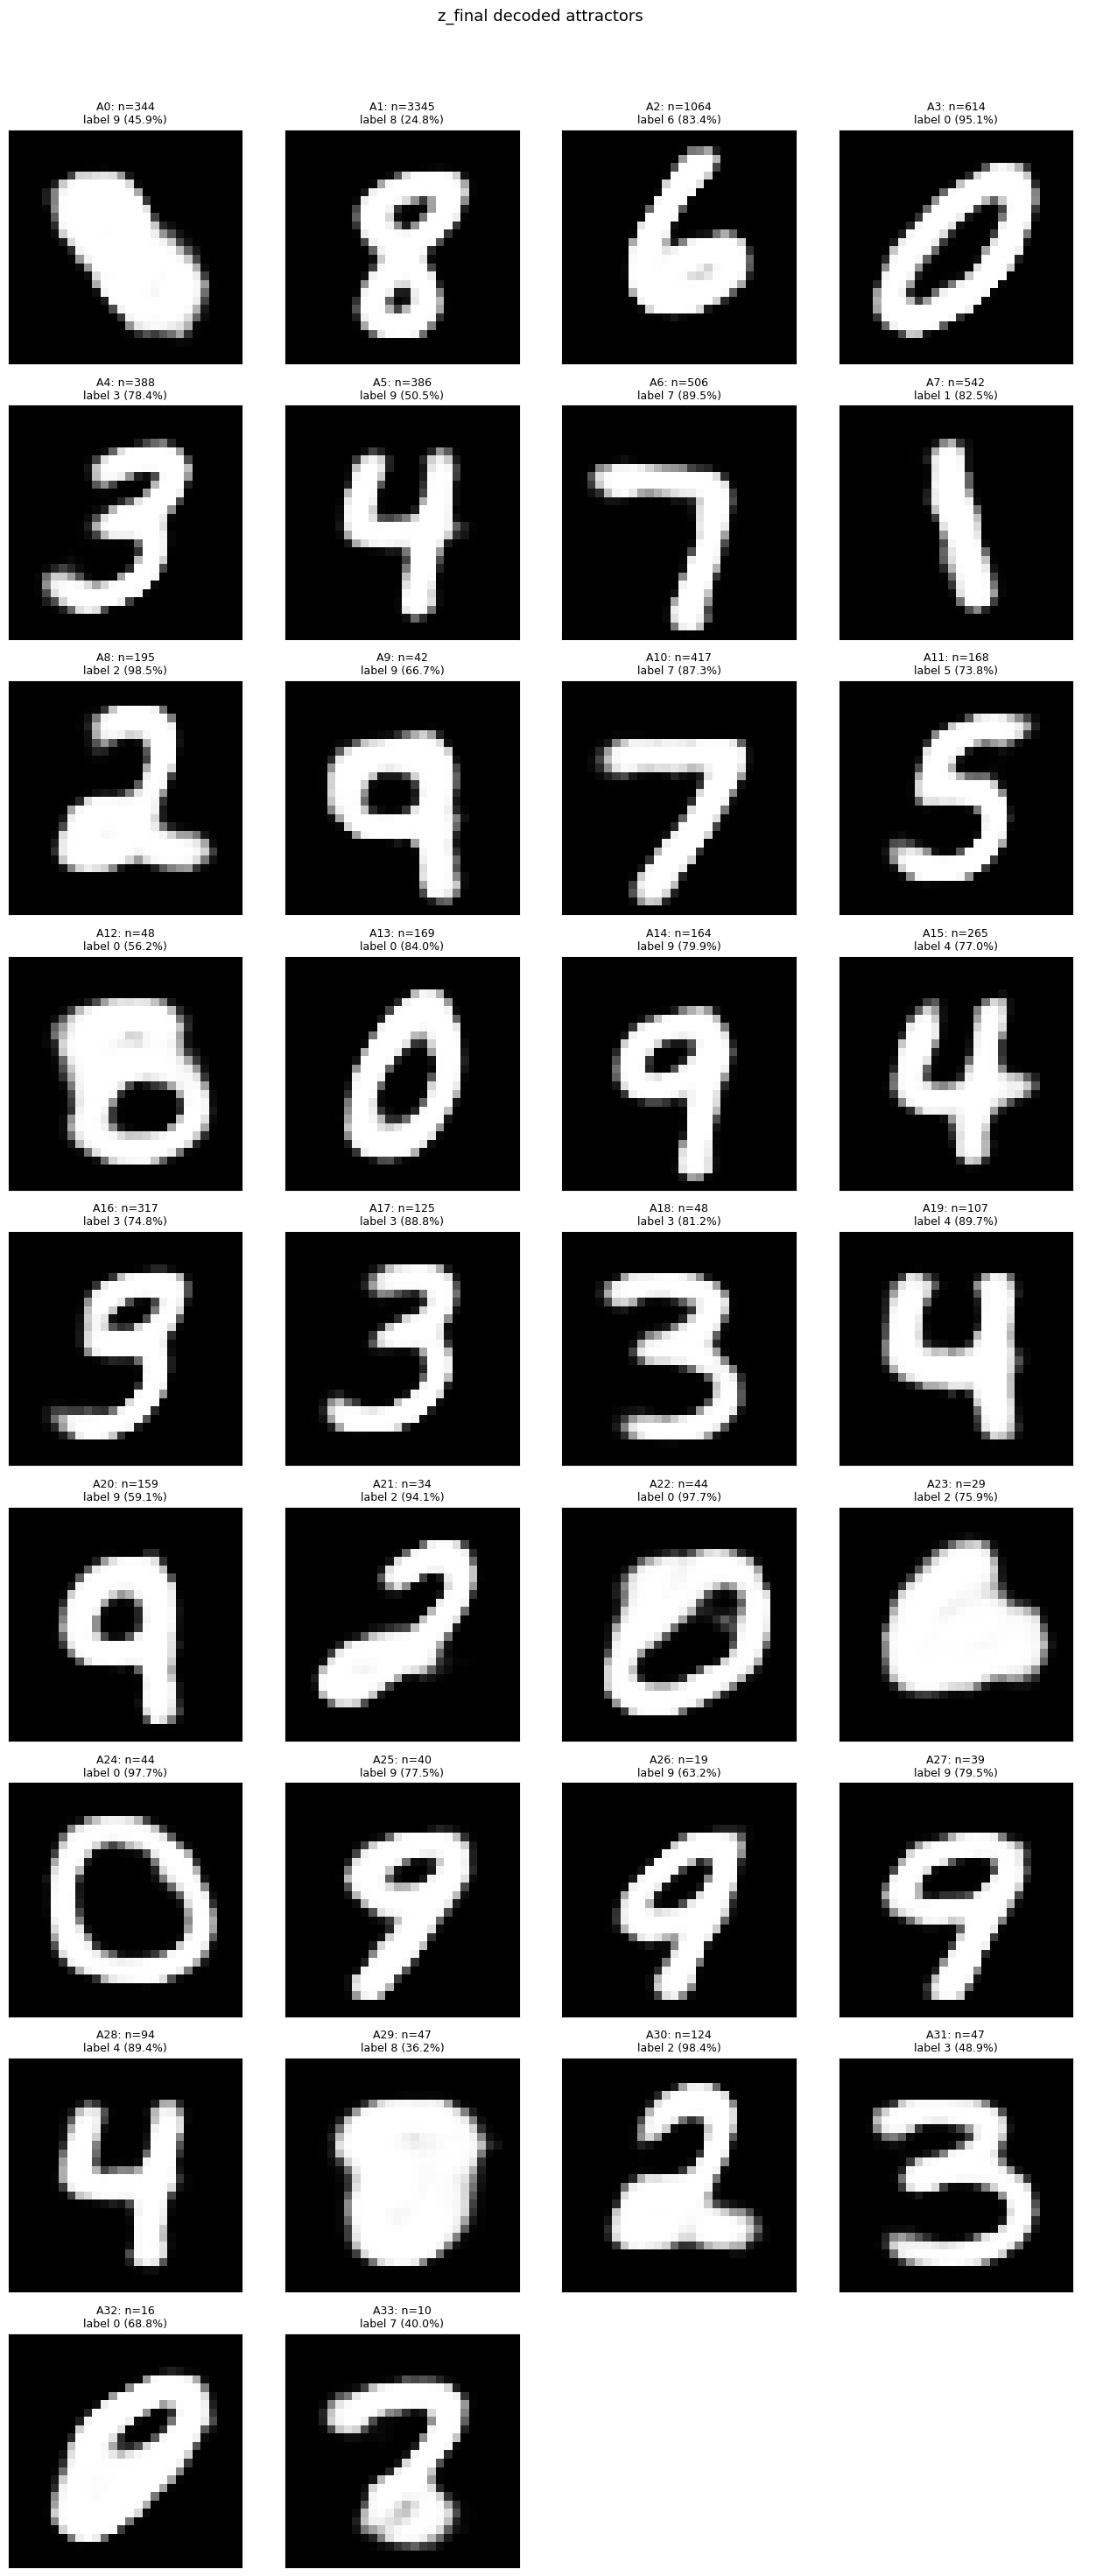


z_final true MNIST label distributions for selected clustering:
Attractor 00 | n=344 | 0:23 (6.7%) | 1:0 (0.0%) | 2:15 (4.4%) | 3:42 (12.2%) | 4:44 (12.8%) | 5:17 (4.9%) | 6:7 (2.0%) | 7:24 (7.0%) | 8:14 (4.1%) | 9:158 (45.9%)
Attractor 01 | n=3345 | 0:39 (1.2%) | 1:681 (20.4%) | 2:482 (14.4%) | 3:150 (4.5%) | 4:248 (7.4%) | 5:550 (16.4%) | 6:31 (0.9%) | 7:119 (3.6%) | 8:828 (24.8%) | 9:217 (6.5%)
Attractor 02 | n=1064 | 0:23 (2.2%) | 1:5 (0.5%) | 2:66 (6.2%) | 3:13 (1.2%) | 4:19 (1.8%) | 5:25 (2.3%) | 6:887 (83.4%) | 7:3 (0.3%) | 8:20 (1.9%) | 9:3 (0.3%)
Attractor 03 | n=614 | 0:584 (95.1%) | 1:0 (0.0%) | 2:10 (1.6%) | 3:2 (0.3%) | 4:4 (0.7%) | 5:1 (0.2%) | 6:7 (1.1%) | 7:1 (0.2%) | 8:2 (0.3%) | 9:3 (0.5%)
Attractor 04 | n=388 | 0:10 (2.6%) | 1:2 (0.5%) | 2:28 (7.2%) | 3:304 (78.4%) | 4:0 (0.0%) | 5:32 (8.2%) | 6:0 (0.0%) | 7:1 (0.3%) | 8:8 (2.1%) | 9:3 (0.8%)
Attractor 05 | n=386 | 0:0 (0.0%) | 1:0 (0.0%) | 2:1 (0.3%) | 3:0 (0.0%) | 4:166 (43.0%) | 5:4 (1.0%) | 6:0 (0.0%) | 7:13 (3.

In [41]:
from matplotlib.lines import Line2D
import math
import matplotlib.pyplot as plt
import numpy as np

def plot_silhouette_overlay_only(res_first, res_final, out_path="Photos/z_first_vs_z_final_silhouette_overlay.png"):
    fig, ax = plt.subplots(figsize=(7.2, 4.6))
    ax.plot(res_first["k_values"], res_first["sil_scores"], color="tab:blue", linewidth=2, marker="o")
    ax.plot(res_final["k_values"], res_final["sil_scores"], color="tab:orange", linewidth=2, marker="s")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.grid(True, alpha=0.25)
    handles = [
        Line2D([0], [0], color="tab:blue", linewidth=2, marker="o"),
        Line2D([0], [0], color="tab:orange", linewidth=2, marker="s"),
    ]
    ax.legend(
        handles=handles,
        labels=["", ""],
        loc="best",
        frameon=True,
        handlelength=2.4,
        handletextpad=0.0,
        borderpad=0.4,
        labelspacing=0.4,
    )
    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved overlay-only silhouette plot -> {out_path}")
    return out_path

def show_selected_attractor_distributions(name, res, save=True, fontsize=9):
    proto_imgs = res["proto_imgs"]
    cluster_sizes = res["cluster_sizes"]
    cluster_label_props = res["cluster_label_props"]
    cluster_label_counts = res["cluster_label_counts"]

    if proto_imgs is None or cluster_sizes is None or cluster_label_props is None:
        raise ValueError("res must contain decoded prototypes and label summaries")

    k = proto_imgs.shape[0]
    n_cols = min(4, k)
    n_rows = math.ceil(k / n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.2 * n_cols, 3.2 * n_rows), squeeze=False)

    for idx in range(n_rows * n_cols):
        ax = axes[idx // n_cols][idx % n_cols]
        if idx >= k:
            ax.axis("off")
            continue

        ax.imshow(proto_imgs[idx, 0], cmap="gray")
        ax.set_xticks([])
        ax.set_yticks([])
        top_label = int(np.argmax(cluster_label_props[idx]))
        top_prop = 100.0 * cluster_label_props[idx, top_label]
        ax.set_title(f"A{idx}: n={cluster_sizes[idx]}\nlabel {top_label} ({top_prop:.1f}%)", fontsize=fontsize)

    plt.suptitle(f"{name} decoded attractors", fontsize=13, y=1.02)
    plt.tight_layout()
    if save:
        out_path = f"Photos/{name}_selected_attractor_distributions.png"
        plt.savefig(out_path, dpi=300, bbox_inches="tight")
        print(f"Saved selected attractor summary -> {out_path}")
    plt.show()

    print(f"\n{name} true MNIST label distributions for selected clustering:")
    for idx in range(k):
        parts = []
        for digit in range(cluster_label_props.shape[1]):
            count = int(cluster_label_counts[idx, digit])
            pct = 100.0 * cluster_label_props[idx, digit]
            parts.append(f"{digit}:{count} ({pct:.1f}%)")
        print(f"Attractor {idx:02d} | n={int(cluster_sizes[idx])} | " + " | ".join(parts))

plot_silhouette_overlay_only(res_first, res_final)
show_selected_attractor_distributions("z_final", res_final)
